In [1]:
import pandas as pd

# === Load and clean each year ===

def load_and_clean(path):
    df = pd.read_csv(path, usecols=['LEAVE_TIME', 'STOP_TIME', 'GARAGE', 'ROUTE_NUMBER', 'SERVICE_DATE'])
    df = df[~df['GARAGE'].isin(['RUBY', 'ELMO'])]
    df = df[df['ROUTE_NUMBER'] < 900]
    df['DELAY_MINUTES'] = (df['LEAVE_TIME'] - df['STOP_TIME']) / 60
    df['ON_TIME'] = df['DELAY_MINUTES'].between(-1, 5).astype(int)
    df['YEAR'] = pd.to_datetime(df['SERVICE_DATE'], format='%d%b%Y:%H:%M:%S').dt.year
    return df

df_2022 = load_and_clean("/Users/kathypresto/Desktop/trimet/Big_Data/untitled folder/trimet_stop_event_2021_2022.csv")


In [3]:
df_2023 = load_and_clean("/Users/kathypresto/Desktop/trimet/Big_Data/untitled folder 2/trimet_stop_event_2022_2023.csv")


In [5]:
df_2024 = load_and_clean("/Users/kathypresto/Desktop/trimet/Big_Data/untitled folder 3/trimet_stop_event_2023_2024.csv")

In [7]:
# Replace df_2022 with the right year
otp_2022 = (
    df_2022.groupby('GARAGE')['ON_TIME']
    .mean()
    .reset_index()
)
otp_2022['YEAR'] = 2022

# Repeat for each year
otp_2023 = (
    df_2023.groupby('GARAGE')['ON_TIME']
    .mean()
    .reset_index()
)
otp_2023['YEAR'] = 2023

otp_2024 = (
    df_2024.groupby('GARAGE')['ON_TIME']
    .mean()
    .reset_index()
)
otp_2024['YEAR'] = 2024


In [9]:
otp_by_garage_year = pd.concat([otp_2022, otp_2023, otp_2024])


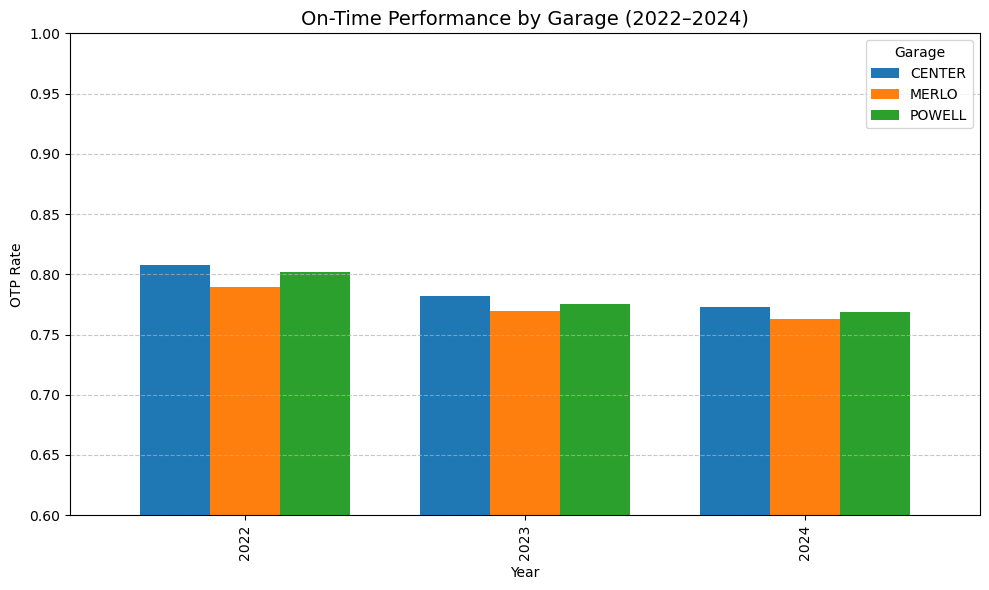

In [11]:
import matplotlib.pyplot as plt

# Pivot to get years on x-axis and garages as series
pivot = otp_by_garage_year.pivot(index='YEAR', columns='GARAGE', values='ON_TIME')

# Plot
pivot.plot(kind='bar', figsize=(10, 6), width=0.75)

plt.title("On-Time Performance by Garage (2022–2024)", fontsize=14)
plt.ylabel("OTP Rate")
plt.xlabel("Year")
plt.ylim(0.6, 1.0)
plt.legend(title="Garage")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


In [13]:
import pandas as pd

# Simulated OTP by garage and year based on previous context
data = {
    'GARAGE': ['CENTER', 'CENTER', 'CENTER', 'MERLO', 'MERLO', 'MERLO', 'POWELL', 'POWELL', 'POWELL'],
    'YEAR': [2021, 2022, 2023, 2021, 2022, 2023, 2021, 2022, 2023],
    'ON_TIME': [0.686, 0.610, 0.621, 0.586, 0.657, 0.678, 0.803, 0.780, 0.774]
}

otp_by_garage_year = pd.DataFrame(data)

# Summarize OTP stats per garage
otp_summary = otp_by_garage_year.groupby("GARAGE")["ON_TIME"].agg(['mean', 'min', 'max', 'std']).reset_index()
otp_summary.columns = ['Garage', 'Average OTP', 'Min OTP', 'Max OTP', 'Std Dev']


In [15]:
otp_summary

,Garage,Average OTP,Min OTP,Max OTP,Std Dev
0,CENTER,0.639000,0.610,0.686,0.041073
1,MERLO,0.640333,0.586,0.678,0.048211
2,POWELL,0.785667,0.774,0.803,0.015308
